## Data vizualization
In this notebook, I will try toimplement meaningful visualization to better understand the structure of the data from patient 3455.
Inspired from subjects_loop.ipynb

In [ ]:
# TODO: - different subjects_dir directories, solve the directories
#      - trans = mne.transforms.Transform('mri', 'head') inconsistent

In [2]:
# General Imports
import os
import numpy as np
import pandas as pd
import matplotlib 
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import re
import os
from datetime import datetime
import pandas as pd
import numpy as np
import mne
import neo

# MNE imports
import mne
from mne.stats import permutation_cluster_test
from mne import Epochs
from mne.time_frequency import EpochsTFRArray
from mne.datasets import fetch_fsaverage
from mne_bids import (
    find_matching_paths,
    read_raw_bids,
)
import mne_bids
from mne_bids import BIDSPath
from mne.datasets import somato

# Set up the 3D backend for MNE visualization
matplotlib.use('Agg') # or nbAgg
mne.viz.set_3d_backend('notebook')

Using notebook 3d backend.


Useful functions :

In [3]:
EXTRA_COLUMNS_DESCRIPTIONS = {
    'stim_onset_unity': 'Stimulus onset time in seconds since the start of the Unity game',
    'resp_onset_unity': 'Response onset time in seconds since the start of the Unity game',
    'duration': 'Duration between stimulus and response in seconds',
    'condition': 'Condition of the trial (Current, Past, Distant Past, Futur, Distant Futur)',
    'correct': 'Whether the response is correct or not (True/False)',
    'validation': 'whether the response is correct or not(Eprime)',
    'stim': 'Stimulus presented to the subject',
    'resp': 'Response given by the subject',
    'correct_year': 'Year that the subject should have answered',
    'year': 'Year during which the subject was asked to answer',
    'cross_time': 'duration of the fixation cross before trial onset',
}

def raw_from_neo(fname):
    seg_micromed = neo.MicromedIO(filename=fname)
    # Date
    date = seg_micromed.raw_annotations['blocks'][0]['rec_datetime']
    print("Date: ", date)
    # Convert the date to UTC
    segment = seg_micromed.read_segment()

    # Because here we have the same on all chan
    sfreq = segment.analogsignals[0].sampling_rate

    data = np.asarray(segment.analogsignals)[0].T
    data *= 1e-6  # putdata from microvolts to volts

    ch_names = [channel[0] for channel in seg_micromed.header['signal_channels']]
    ch_types = ['stim' if 'MKR' in ch_name else 'ecg' if 'ECG' in ch_name else 'misc' if 'EX' in ch_name else 'stim' if 'PHOTO' in ch_name else 'stim' if 'photo' in ch_name else 'seeg' for ch_name in ch_names]
 
    info = mne.create_info(ch_names, sfreq, ch_types=ch_types)
    raw = mne.io.RawArray(data, info)
    return(raw)


def seeg_ch_name_split(name):
    elec, idx = re.match(r'([A-Za-z]+)(\d+)', name).groups()
    return elec, int(idx)


def find_anodes_cathodes(raw):
    anodes, cathodes = [], []
    for i in range(len(raw.ch_names)-1):
        if raw.get_channel_types()[i:i+2]==['seeg', 'seeg']:
            (e1, i1), (e2, i2) = map(seeg_ch_name_split, raw.ch_names[i:i+2])
            if e1==e2:
                anodes.append(e1 + str(i1))
                cathodes.append(e2 + str(i2))
    return (anodes, cathodes)


def read_montage(subject, subjects_dir):
    # ii. import electrodes
    ch_coords_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.PIAL'), sep=' ', header=1)
    ch_coords = ch_coords_df[['R', 'A', 'S']].to_numpy(dtype=float)/1000. # put in mm
    ch_names_df = pd.read_csv(os.path.join(subjects_dir, subject, 'elec_recon', subject + '.electrodeNames'), sep=' ', header=1, names=['name', 'Depth', 'hemisphere'])
    ch_names = ch_names_df['name'].tolist()
    ch_pos = dict(zip(ch_names, ch_coords))
    lpa, nasion, rpa = mne.coreg.get_mni_fiducials(subject, subjects_dir=subjects_dir)
    lpa, nasion, rpa = lpa['r'], nasion['r'], rpa['r']
    montage_head = mne.channels.make_dig_montage(ch_pos, coord_frame='mri', nasion=nasion, lpa=lpa, rpa=rpa)
    return(montage_head)


def read_events(fname):
    dicts = list()
    with open(fname) as f:
        content = f.readlines()
        for line in content:
            if line.startswith("UniqueID"):
                ID, Q, year, stim, _, _, _, resp, correct_year, validation, Game, cross_time, stim_onset, resp_time, resp_onset = line.split(" | ")
                
                ID = int(ID.split(":")[1])
                Q = int(Q.split("#")[1])
                year = int(year.split(":")[1])
                stim = stim.split(":")[1]
                resp = resp.split(":")[1].split("(")[0].strip()
                correct_year = correct_year.split(":")[1].strip()
                validation = validation.split(":")[1]
                Game = Game.split("#")[1]
                cross_time = float(cross_time.split(":")[1])
                stim_onset = datetime.strptime(stim_onset.split("displayed:")[1].strip(), "%H:%M:%S:%f")
                resp_time = float(resp_time.split(":")[1])
                resp_onset = datetime.strptime(resp_onset.split("answered:")[1].strip(), "%H:%M:%S:%f")
                data ={
                        "ID": ID,
                        "Q": Q,
                        "year": year,
                        "stim": stim,
                        "resp": resp,
                        "correct_year": correct_year,
                        "validation": validation,
                        "Game": Game,
                        "cross_time": cross_time,
                        "stim_onset": stim_onset,
                        "resp_time": resp_time,
                        "resp_onset": resp_onset
                    }
                dicts.append(data)

    unity_start = content[0].split('|')[0].split('Time:')[1].strip()
    unity_start = datetime.strptime(unity_start, "%H:%M:%S:%f")

    first_photo = content[2].split('completed:')[1].strip()
    first_photo = datetime.strptime(first_photo, "%H:%M:%S:%f")

    df = pd.DataFrame(dicts)

    df['stim_onset_unity'] = df['stim_onset'] - unity_start
    df['stim_onset_unity'] = [stim.total_seconds() for stim in df['stim_onset_unity']]
    df['resp_onset_unity'] = df['resp_onset'] - unity_start
    df['resp_onset_unity'] = [resp.total_seconds() for resp in df['resp_onset_unity']]
    df['duration'] = df['resp_onset_unity'] - df['stim_onset_unity']

    conditions = []
    correct = []
    for r, row in df.iterrows():
        current_year = row['year']
        correct_year = row['correct_year']
        resp = row['resp']
        # Condition
        if correct_year in ['Never', 'Always']:
            condition = correct_year
        else:
            distance = int(correct_year) - int(current_year)
            if distance == 0:
                condition = "Current"
            elif distance == -1:
                condition = "Past"
            elif distance  < -1:
                condition = "Distant Past"
            elif distance == 1:
                condition = "Futur"
            elif distance > 1:
                condition = "Distant Futur"
        conditions.append(condition)

        if resp == 'C':
            response = 'Current'
        elif resp == 'A':
            response = 'Always'
        elif resp == 'N':
            response = 'Never'
        elif resp == '+1':
            response = 'Futur'
        elif resp == '-1':
            response = 'Past'
        elif resp == '+2':
            response = 'Distant Futur'
        elif resp == '-2':
            response = 'Distant Past'
        else:
            raise ValueError(f"Unknown response: {resp}")
        
        if response == condition:
            correct.append(True)
        else:
            correct.append(False)

    df['condition'] = conditions
    df['correct'] = correct
    df['validation'] = df['validation'].astype(bool)

    return(df)

Parameters :

In [4]:
# Choose between TRC data or BIDS data
data_source = "TRC" # "TRC" or "BIDS" or "Check" (for comparing outputs of both)(If check chosen, notebook will be executed with TRC data)

# Electrode Referencing type
reference = "bipolar" # "bipolar" or "no_reference" or ...

# TODO - solve the patient and subject variables, maybe create a mapping between them
patient = "PAT_3455"
subject = "02"

if data_source not in ["BIDS", "TRC", "Check"]:
    raise ValueError("Data source must be either TRC or BIDS (or Check)")

Process the data :

In [ ]:
# BIDS root
bids_root = Path("/media/RCPNAS/sEEG_MARS_Alison")

# FreeSurfer subjects directory - contains reconstructions for all patients, including PAT3455
fs_subjects_dir = Path("/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions") 

# Check participants.tsv for mapping
participants_file = bids_root / "participants.tsv"
if participants_file.exists():
    participants = pd.read_csv(participants_file, sep='\t')
    print("Participants mapping:")
    print(participants)

# Verify the PAT3455 subject exists
pat_path = fs_subjects_dir / patient
print(f"PAT path exists: {pat_path.exists()}")
if pat_path.exists():
    print("Found FreeSurfer subject PAT with directories:")
    print([d.name for d in pat_path.iterdir() if d.is_dir()])

# TODO: Now create mapping for all subjects
subject_to_fs = {
    "02": patient, 
}

# Process sub-02
session = "retrieval"
task = "mars"
fs_subject = subject_to_fs[subject]
print(f"\nProcessing {subject} → FreeSurfer subject: {fs_subject}")
print(f"FreeSurfer directory: {fs_subjects_dir / fs_subject}")

# Create BIDS path from bids_root
bids_path = BIDSPath(
    subject=subject,
    session=session,
    task=task,
    datatype="ieeg",
    root=bids_root,
    suffix="ieeg",
    extension=".vhdr"
)

# Read data
if data_source == "BIDS" or data_source == "Check":
    print(f"\nLoading data from: {bids_path.fpath}")
    raw = read_raw_bids(bids_path, verbose=False)
    raw_bids = raw.copy()

if data_source == "TRC" or data_source == "Check":
    fname_events = fr"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/stims/sub-02/P2/Unity_experiment/Experiment_698092.txt"
    fname_raw = r"/media/RCPNAS/sEEG_MARS_Alison/sourcedata/seeg/sub-02/PA_1987/EEG_6865.TRC"

    print(f"\n--- Traitement TRC ---")
    df = read_events(fname_events)
    raw = raw_from_neo(fname_raw)

    if 'photo' in raw.ch_names:
        raw.rename_channels({'photo': 'photodiode'})
    
    if 'ECG-' in raw.ch_names and 'ECG+' in raw.ch_names:
        raw = mne.set_bipolar_reference(raw, 'ECG-', 'ECG+', ch_name='ECG', drop_refs=True)
        raw.set_channel_types({'ECG': 'ecg'})

    delay = (1844.475 - 333.112) # TODO: Comment est calculé ce délai?
    df['stim_onset_abs'] = df['stim_onset_unity'] + delay
    df['resp_onset_abs'] = df['resp_onset_unity'] + delay

    tmin_abs = 1600
    tmax_abs = 3200

    print(f"Durée originale du signal : {raw.times[-1]:.2f}s")
    raw.crop(tmin=tmin_abs, tmax=tmax_abs)
    print(f"Durée après crop ({tmin_abs}-{tmax_abs}) : {raw.times[-1]:.2f}s")

    raw = raw.copy() 

    mask = (df['stim_onset_abs'] >= tmin_abs) & (df['stim_onset_abs'] <= tmax_abs)
    df_filtered = df[mask].reset_index(drop=True)

    if len(df_filtered) == 0:
        print("ERREUR CRITIQUE : Aucun événement ne tombe dans la fenêtre [1600, 3200]s !")
        print(f"Vérifiez vos colonnes 'stim_onset_unity' et le délai calculé ({delay}).")
        print(f"Min stim_onset_abs: {df['stim_onset_abs'].min()}, Max: {df['stim_onset_abs'].max()}")
    else:
        df_filtered['onset_rel'] = df_filtered['stim_onset_abs'] - tmin_abs
        
        onsets = df_filtered['onset_rel'].values
        durations = df_filtered['duration'].values
        descriptions = df_filtered['condition'].values

        valid_idx = ~np.isnan(onsets) & ~np.isnan(durations)
        onsets = onsets[valid_idx]
        durations = durations[valid_idx]
        descriptions = descriptions[valid_idx]

        annotations = mne.Annotations(
            onset=onsets,
            duration=durations,
            description=descriptions.astype(str)
        )
        
        raw.set_annotations(annotations)

        print(f"Nombre d'annotations dans l'objet raw : {len(raw.annotations)}")
        if len(raw.annotations) > 0:
            print(f"Exemple d'annotation : {raw.annotations[0]}")
        else:
            print("ÉCHEC : Les annotations n'ont pas été enregistrées malgré la création.")

    raw_trc = raw.copy()

trc_channel_names = raw.ch_names
print(f"TRC channel names (first 10): {trc_channel_names[:10]}")
print(f"Total channels: {len(trc_channel_names)}")


# Path to electrode reconstruction files
elec_recon_path = bids_root / "sourcedata" / "reconstructions" / "PAT_3455" / "elec_recon"
coord_type = "LEPTO"  # Use LEPTO !!!!!
coord_file = elec_recon_path / f"PAT_3455.{coord_type}"
print(f"\nLoading coordinates from: {coord_file}")
print(f"File exists: {coord_file.exists()}")

# Load bad annotations
bad_annotation_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_annot.csv"

if bad_annotation_path.exists():
    # Check if file is empty (size 0) or has only headers
    if bad_annotation_path.stat().st_size == 0:
        print(f"Warning: {bad_annotation_path} is empty. Skipping.")
        bad_annotations = mne.Annotations(onset=[], duration=[], description=[])
    else:
        try:
            # Try reading with pandas first to check content
            df_test = pd.read_csv(bad_annotation_path)
            if df_test.empty:
                print(f"Warning: {bad_annotation_path} has no data rows. Skipping.")
                bad_annotations = mne.Annotations(onset=[], duration=[], description=[])
            else:
                # File has data, proceed with MNE
                bad_annotations = mne.read_annotations(bad_annotation_path)
                
                # Sync orig_time if needed
                if raw.annotations.orig_time is not None:
                    bad_annotations = mne.Annotations(
                        onset=bad_annotations.onset,
                        duration=bad_annotations.duration,
                        description=bad_annotations.description,
                        orig_time=raw.annotations.orig_time
                    )
        except Exception as e:
            print(f"Error reading {bad_annotation_path}: {e}")
            bad_annotations = mne.Annotations(onset=[], duration=[], description=[])

    # Add to raw
    raw.set_annotations(raw.annotations + bad_annotations)
    print(f"Added {len(bad_annotations)} bad segments.")


# Clean the coordinates and creates a montage that matches the TRC channels
if coord_file.exists():
    # Read the coordinate file
    # These are typically text files with coordinates in mm
    coords = []
    with open(coord_file, 'r') as f:
        for line in f:
            line = line.strip()
            if line and not line.startswith('#'):  # Skip empty lines and comments
                try:
                    # Parse x y z coordinates
                    parts = line.split()
                    if len(parts) >= 3:
                        x, y, z = float(parts[0]), float(parts[1]), float(parts[2])
                        coords.append([x, y, z])
                except:
                    continue
    
    coords = np.array(coords)
    print(f"Loaded {len(coords)} coordinates")
    
    # Also load electrode names if available
    names_file = elec_recon_path / "PAT_3455.electrodeNames"
    if names_file.exists():
        with open(names_file, 'r') as f:
            electrode_names = [line.strip() for line in f if line.strip() and not line.startswith('#')]
        print(f"Loaded {len(electrode_names)} electrode names")
    else:
        electrode_names = [f"ELEC{i+1:03d}" for i in range(len(coords))]
    
    # Check if number matches TRC channels
    print(f"\nCoordinate count: {len(coords)}")
    print(f"TRC channel count: {len(trc_channel_names)}")
    print(f"Electrode names count: {len(electrode_names)}")
    
    if len(coords) == len(trc_channel_names):
        print(" Coordinate count matches TRC channels - using as-is")
        montage_coords = coords
        montage_names = trc_channel_names
    else:
        print(" Count mismatch - need to map coordinates to TRC channels")
        
        # Create mapping dictionary
        coord_dict = dict(zip(electrode_names, coords))
        
        # Map to TRC order
        montage_coords = []
        montage_names = []
        
        for ch_name in trc_channel_names:
            # Try exact match first
            if ch_name in coord_dict:
                montage_coords.append(coord_dict[ch_name])
                montage_names.append(ch_name)
            else:
                # Try without spaces/special chars
                ch_clean = ch_name.replace(' ', '').replace('-', '').replace("'", "")
                found = False
                for coord_name in coord_dict.keys():
                    coord_clean = coord_name.replace(' ', '').replace('-', '').replace("'", "")
                    if ch_clean in coord_clean or coord_clean in ch_clean:
                        montage_coords.append(coord_dict[coord_name])
                        montage_names.append(ch_name)
                        print(f"  Matched {ch_name} to {coord_name}")
                        found = True
                        break
                
                if not found:
                    print(f"  Warning: No match for {ch_name}")
                    montage_coords.append([np.nan, np.nan, np.nan])
                    montage_names.append(ch_name)
        
        montage_coords = np.array(montage_coords)
    montage_coords = montage_coords / 1000  # Convert mm to m for MNE
    
    # Create montage
    montage = mne.channels.make_dig_montage(
        ch_pos=dict(zip(montage_names, montage_coords)),
        coord_frame='mri'  # These are in MRI coordinates
    )
    
    # Set montage to raw
    raw.set_montage(montage)
    print(f"\n✓ Created montage with {len(montage_names)} electrodes")
    
    # Verify first few electrodes
    print("\nFirst 5 electrode positions:")
    for i, ch_name in enumerate(montage_names[:5]):
        pos = montage.get_positions()['ch_pos'][ch_name]
        print(f"  {ch_name}: ({pos[0]}, {pos[1]:.1f}, {pos[2]:.1f})")
    
    # Save montage for future use
    montage_path = Path.cwd() / f"sub-{subject}_montage.fif"
    montage.save(montage_path, overwrite=True)
    print(f"Saved montage to {montage_path}")
    
    # Now you can get volume labels if FreeSurfer subject exists
    fs_subject = "PAT_3455"
    subjects_dir = bids_root / "sourcedata" / "reconstructions"
    
    aparcaseg_path = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455/mri/aparc+aseg.mgz"

    if Path(aparcaseg_path).exists():
        try:
            labels, colors = mne.get_montage_volume_labels(
                montage,
                fs_subject,
                subjects_dir=str(subjects_dir),
                aseg="aparc+aseg"
            )
            
            # labels and colors are dicts keyed by channel name
            # Build DataFrame from the dicts directly
            results_df = pd.DataFrame({
                'channel': list(labels.keys()),
                'label': [labels[ch] for ch in labels.keys()],
                'color': [colors[ch] for ch in labels.keys()]
            })
            
            output_path = Path.cwd() / f"sub-{subject}_electrode_labels.csv"
            results_df.to_csv(output_path, index=False)
            print(f"Saved electrode labels to {output_path}")
            print(results_df.head())
            
        except Exception as e:
            print(f"Could not get volume labels: {e}")

if coord_file.exists() == False:
    montage = None

# Now visualize electrodes on brain
print(f"\nCreating brain visualization for {fs_subject}")

# Create brain
brain = mne.viz.Brain(
    fs_subject,
    subjects_dir=str(fs_subjects_dir),
    cortex="low_contrast",
    alpha=0.25,
    background="white",
    figure=1,
)

# Add electrodes if montage exists
if montage is not None:
    try:
        # TODO: Check the transform
        trans = mne.transforms.Transform('head', 'mri')  # TODO: Why does the inverse trans give the same result
        brain.add_sensors(raw.info, trans=trans)
        print("Added electrodes to brain")
    except Exception as e:
        print(f"Could not add electrodes: {e}")

print(f"Montage exists: {montage is not None}")

if montage is None:
    print("\nNo montage found in raw data.")
    print("Looking for electrodes.tsv file...")
    
    # Look for electrodes.tsv
    electrodes_path = bids_root / f"sub-{subject}" / f"ses-{session}" / "ieeg" / f"sub-{subject}_ses-{session}_task-{task}_electrodes.tsv"
    print(f"Electrodes file exists: {electrodes_path.exists()}")
    
    if electrodes_path.exists():
        # Read electrodes.tsv
        electrodes_df = pd.read_csv(electrodes_path, sep='\t')
        print(f"\nElectrodes file contents:")
        print(f"Columns: {electrodes_df.columns.tolist()}")
        print(f"Number of electrodes: {len(electrodes_df)}")
        print("\nFirst few electrodes:")
        print(electrodes_df.head())
        
        # Check coordinate columns
        coord_cols = ['x', 'y', 'z']
        if all(col in electrodes_df.columns for col in coord_cols):
            print("\n✓ Found coordinate columns (x, y, z)")
            
            # Create montage
            montage = mne.channels.make_dig_montage(
                ch_pos=dict(zip(electrodes_df['name'], 
                               electrodes_df[coord_cols].values)),
                coord_frame='mri'  # or 'head' - check which one
            )
            raw.set_montage(montage)
            print(f"Created and set montage with {len(electrodes_df)} electrodes")
        else:
            print(f"Expected coordinate columns not found. Available columns: {electrodes_df.columns.tolist()}")
    else:
        print("No electrodes.tsv file found in BIDS directory")
        
        # Look for alternative coordinate files
        coord_files = list(Path(bids_root / f"sub-{subject}").rglob("*coord*"))
        print(f"Alternative coordinate files found: {coord_files}")

# Save images
output_dir = Path.cwd() / "figures"
output_dir.mkdir(exist_ok=True)

# Save different views
views = [
    ("lateral_right", dict(azimuth=90, elevation=90, distance=400)),
    ("lateral_left", dict(azimuth=-90, elevation=90, distance=400)),
    ("top", dict(azimuth=0, elevation=90, distance=400)),
    ("front", dict(azimuth=0, elevation=0, distance=400)),
    ("back", dict(azimuth=180, elevation=0, distance=400)),
]

for view_name, view_kwargs in views:
    brain.show_view(**view_kwargs)
    output_file = output_dir / f"{subject}_electrodes_{view_name}.png"
    brain.save_image(str(output_file))
    print(f"Saved: {output_file}")

brain.close()
print(f"\nAll images saved to {output_dir}")

Participants mapping:
  participant_id  age  sex  hand  weight  height
0         sub-01  NaN  NaN   NaN     NaN     NaN
1         sub-02  NaN  NaN   NaN     NaN     NaN
2         sub-03  NaN  NaN   NaN     NaN     NaN
3         sub-04  NaN  NaN   NaN     NaN     NaN
4         sub-06  NaN  NaN   NaN     NaN     NaN
PAT path exists: True
Found FreeSurfer subject PAT with directories:
['mri', 'tmp', 'stats', 'surf_old', 'touch', 'trash', 'surf', 'voxeloc', 'elec_recon_pierre_voxeloc', 'label', 'bem', 'mri_old', 'scripts', 'elec_recon', 'label_old', 'elec_recon_old']

Processing 02 → FreeSurfer subject: PAT_3455
FreeSurfer directory: /media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions/PAT_3455

--- Traitement TRC ---
Date:  2022-06-18 09:29:27
Creating RawArray with float64 data, n_channels=121, n_times=8601728
    Range : 0 ... 8601727 =      0.000 ...  4200.062 secs
Ready.
sEEG channel type selected for re-referencing
Creating RawArray with float64 data, n_channels=1, n_times=86017

/tmp/ipykernel_2961182/2781290079.py:157: RuntimeWarning: Omitted 120 annotation(s) that were outside data range.
  raw.set_annotations(raw.annotations + bad_annotations)
/tmp/ipykernel_2961182/2781290079.py:243: RuntimeWarning: Fiducial point nasion not found, assuming identity unknown to head transformation
  raw.set_montage(montage)
/tmp/ipykernel_2961182/2781290079.py:243: RuntimeWarning: Not setting positions of 4 ecg/stim channels found in montage:
['MKR1+', 'photodiode', 'MKR2+', 'ECG']
Consider setting the channel types to be of EEG/sEEG/ECoG/DBS/fNIRS using inst.set_channel_types before calling inst.set_montage, or omit these channels when creating your montage.
  raw.set_montage(montage)
/tmp/ipykernel_2961182/2781290079.py:254: RuntimeWarning: This filename (/home/aboschun/MIPlab-Project/sub-02_montage.fif) does not conform to MNE naming conventions. All montage files should end with -dig.fif or -dig.fif.gz
  montage.save(montage_path, overwrite=True)


Saved montage to /home/aboschun/MIPlab-Project/sub-02_montage.fif
Could not get volume labels: 'AD1'

Creating brain visualization for PAT_3455


2026-03-23 17:21:19.433 ( 160.347s) [    7FE33D72C4C0]vtkXOpenGLRenderWindow.:1460  WARN| bad X server connection. DISPLAY=


Channel types::	seeg: 116
Added electrodes to brain
Montage exists: True
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_lateral_right.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_lateral_left.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_top.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_front.png
Saved: /home/aboschun/MIPlab-Project/figures/02_electrodes_back.png

All images saved to /home/aboschun/MIPlab-Project/figures


In [6]:
# Annotations fail if not executed
if data_source == "TRC" or data_source == "Check":
    raw.set_annotations(annotations)
    raw.annotations

In [7]:
if data_source == "Check":
    # Compare BIDS and TRC raw files
    print(raw_bids)
    print(raw_trc)
    # Verify what actually matters
    print(f"Sfreq:    BIDS={raw_bids.info['sfreq']}, TRC={raw_trc.info['sfreq']}")
    print(f"N times:  BIDS={len(raw_bids.times)}, TRC={len(raw_trc.times)}")
    print(f"N ch:     BIDS={len(raw_bids.ch_names)}, TRC={len(raw_trc.ch_names)}")
    print(f"Ch match: {raw_bids.ch_names == raw_trc.ch_names}")
    print(f"Ch types match: {raw_bids.get_channel_types() == raw_trc.get_channel_types()}")

Check montage's electrodes positions :

In [8]:
montage.get_positions()

{'ch_pos': OrderedDict([('AD1',
               array([ 0.02545176, -0.00344268, -0.00522475])),
              ('AD2', array([ 0.02867764, -0.00266402, -0.00633712])),
              ('AD3', array([ 0.03190353, -0.00188536, -0.00744949])),
              ('AD4', array([ 0.03512941, -0.00110669, -0.00856186])),
              ('AD5', array([ 0.03835529, -0.00032803, -0.00967424])),
              ('AD6', array([ 0.04158117,  0.00045063, -0.01078661])),
              ('AD7', array([ 0.021, -0.019, -0.003])),
              ('AD8', array([ 0.02427734, -0.01780824, -0.00329794])),
              ('HAD1', array([ 0.02755468, -0.01661648, -0.00359588])),
              ('HAD2', array([ 0.03083201, -0.01542472, -0.00389382])),
              ('HAD3', array([ 0.03410935, -0.01423296, -0.00419176])),
              ('HAD4', array([ 0.03738669, -0.0130412 , -0.0044897 ])),
              ('HAD5', array([ 0.04066403, -0.01184945, -0.00478764])),
              ('HAD6', array([ 0.04394136, -0.01065769, -0.005

Keep electrodes that are relevant to our study (hippocampus region) :

In [9]:
aseg = "aparc+aseg"  # parcellation/anatomical segmentation atlas
path_atlas = "/media/RCPNAS/sEEG_MARS_Alison/sourcedata/reconstructions"

# Get volume labels for each electrode based on the montage and FreeSurfer subject
labels, colors = mne.get_montage_volume_labels(
    montage, patient, subjects_dir=path_atlas, aseg=aseg
)
print(f"Labels: {labels}")

# Separate by electrodes which have names like LAMY 1
electrodes = set(
    [
        "".join([lttr for lttr in ch_name if not lttr.isdigit() and lttr != " "])
        for ch_name in montage.ch_names
    ]
)
print(f"Electrodes in the dataset: {electrodes}")

# Define regions of interest (ROIs) to keep
regions_of_interest = {
    "ctx-rh-parahippocampal",
    "ctx-rh-fusiform",
    "Right-Hippocampus",
    "ctx-lh-parahippocampal",
    "ctx-lh-fusiform",
    "Left-Hippocampus",
}

# Get labels that correspond to the ROIs --> electrodes that are in the regions of interest
filtered_labels = {
    ch: region_list
    for ch, region_list in labels.items()
    if any(r in regions_of_interest for r in region_list)
}

print(f"Kept {len(filtered_labels)}/{len(labels)} electrodes")
for ch, regions in filtered_labels.items():
    print(f"  {ch}: {regions}")

# New set of electrodes that have labels in the ROIs
filtered_electrodes = set([ch.split(" ")[0] for ch in filtered_labels.keys()])
filtered_channels = list(filtered_labels.keys()) 

# Plot their ROIs
fig, ax = mne.viz.plot_channel_labels_circle(filtered_labels, colors, picks=list(filtered_electrodes))
fig.text(0.3, 0.9, "Anatomical Labels", color="white")
fig.savefig(f"figures/{subject}_allelec_labels.png", dpi=300)

Labels: OrderedDict({'AD1': ['Right-Cerebral-White-Matter', 'Right-Amygdala'], 'AD2': ['Right-Cerebral-White-Matter'], 'AD3': ['Right-Cerebral-White-Matter'], 'AD4': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD5': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD6': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'AD7': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'AD8': ['Right-Cerebral-White-Matter', 'Right-Hippocampus'], 'HAD1': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus'], 'HAD2': ['Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent', 'Right-Hippocampus', 'ctx-rh-fusiform'], 'HAD3': ['Unknown', 'Right-Cerebral-White-Matter', 'Right-Inf-Lat-Vent'], 'HAD4': ['Right-Cerebral-White-Matter'], 'HAD5': ['Right-Cerebral-White-Matter'], 'HAD6': ['Right-Cerebral-White-Matter', 'ctx-rh-inferiortemporal'], 'HAD7': ['Right-Cerebral-White-Matter', 'ctx-rh-middletemporal'], 'HAD8': ['Right-Cerebral-White-Matter', 'ctx-rh

Check annotations and time data, it seems that there is a mismatch (TRC and Bids data do not give the same results)

In [10]:
def check_annotations_and_timing(raw):
    # Check annotations and time data, it seems that there is a mismatch (TRC and Bids data do not give the same results)
    print("=== Annotations ===")
    print(raw.annotations)
    print(f"\nAnnotation descriptions: {set(raw.annotations.description)}")
    print(f"Number of annotations: {len(raw.annotations)}")

    # Check timing
    print("\n=== Timing ===")
    print(f"First sample time: {raw.times[0]:.4f} s")
    print(f"Last sample time:  {raw.times[-1]:.4f} s")
    print(f"Duration:          {raw.times[-1] - raw.times[0]:.4f} s")
    print(f"Sampling frequency: {raw.info['sfreq']} Hz")
    print(f"N samples: {len(raw.times)}")

    # Check for mismatch between annotation onsets and recording time range
    t_start = raw.times[0]
    t_end = raw.times[-1]
    out_of_range = [(desc, onset) for desc, onset in zip(raw.annotations.description, raw.annotations.onset)
                    if onset < t_start or onset > t_end]

    print("\n=== Out-of-range annotations ===")
    if out_of_range:
        for desc, onset in out_of_range:
            print(f"  '{desc}' at {onset:.4f} s  (recording: {t_start:.4f} - {t_end:.4f} s)")
    else:
        print("  All annotations are within the recording time range.")

Filter the raw data of the relevant electrodes :

In [11]:
raw_filtered = raw.copy().pick_channels(filtered_electrodes) # TODO : test with all electrodes
# Filter raw signals
raw_filtered.load_data()
raw_filtered.filter(.1, None, picks='seeg', fir_design='firwin', n_jobs=9)
# low-pass filter < 250 Hz
raw_filtered.filter(None, 250, picks='seeg', fir_design='firwin', n_jobs=9)
# remove power line 50 Hz and harmonics
for ifreq in np.arange(50, 251, 50):
    raw_filtered.notch_filter(ifreq, 
                     picks='seeg', 
                     notch_widths=4,
                     method='iir', 
                     iir_params={'order':6, 'ftype':'butter'},
                     n_jobs=9)

NOTE: pick_channels() is a legacy function. New code should use inst.pick(...).
Filtering raw data in 1 contiguous segment
Setting up high-pass filter at 0.1 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal highpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 0.10
- Lower transition bandwidth: 0.10 Hz (-6 dB cutoff frequency: 0.05 Hz)
- Filter length: 67585 samples (33.000 s)



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    8.4s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    8.8s remaining:    2.7s


Filtering raw data in 1 contiguous segment
Setting up low-pass filter at 2.5e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal lowpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Upper passband edge: 250.00 Hz
- Upper transition bandwidth: 62.50 Hz (-6 dB cutoff frequency: 281.25 Hz)
- Filter length: 109 samples (0.053 s)



[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    9.3s finished
[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    2.3s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.7s remaining:    0.8s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    3.0s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 48 - 52 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 47.50, 52.50 Hz: -6.02, -6.02 dB



...

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    2.1s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.4s remaining:    0.7s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    2.7s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 2e+02 - 2e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 197.50, 202.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    2.3s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.7s remaining:    0.8s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    3.2s finished


Filtering raw data in 1 contiguous segment
Setting up band-stop filter from 2.5e+02 - 2.5e+02 Hz

IIR filter parameters
---------------------
Butterworth bandstop zero-phase (two-pass forward and reverse) non-causal filter:
- Filter order 24 (effective, after forward-backward)
- Cutoffs at 247.50, 252.50 Hz: -6.02, -6.02 dB



[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    1.7s
[Parallel(n_jobs=9)]: Done  13 out of  17 | elapsed:    2.3s remaining:    0.7s
[Parallel(n_jobs=9)]: Done  17 out of  17 | elapsed:    2.5s finished


In [12]:
# Sanity check
raw_filtered.annotations

<Annotations | 120 segments: Always (20), Current (20), Distant Futur ...>

Let's separate the average evoked response for the 7 different conditions:

In [13]:
if data_source == "TRC" or data_source == "Check":
    print(df)

         ID    Q  year                     stim resp correct_year  validation  \
0    698092    0     1   Faire des mots croisés    C            1        True   
1    698092    1     1      Unité Communication    C            3        True   
2    698092    2     1    Compartiment équipage    N        Never        True   
3    698092    3     1         Haut combinaison    A            2        True   
4    698092    4     1     Train d'atterrissage    A       Always        True   
..      ...  ...   ...                      ...  ...          ...         ...   
115  698092  115     4                   Pompes   -1            4        True   
116  698092  116     4    Jouer aux jeux vidéos    A       Always        True   
117  698092  117     4   Faire des mots croisés   -2            1        True   
118  698092  118     4         Haut combinaison   -2            2        True   
119  698092  119     4     Train d'atterrissage    A       Always        True   

    Game  cross_time       

In [14]:
if data_source == "BIDS":
    print("BIDS")
    annot_df = raw_filtered.annotations.to_data_frame()
    # Create event id from macthing description and condition
    print(annot_df['description'])
    print(annot_df['condition'])

    event_id_for_events = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id_for_events and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id_for_events[str(desc)] = int(desc)  # Assign a unique integer ID
    print(f"Event ID mapping: {event_id_for_events}")

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id_for_events.items()}
    )

    # Change events to correct conditions
    event_id = {}
    for desc, cond in zip(annot_df['description'], annot_df['condition']):
        if cond not in event_id and cond in ['Current', 'Past', 'Distant Past', 'Futur', 'Distant Futur', 'Always', 'Never']:
            event_id[str(cond)] = int(desc)  # Assign a unique integer ID
    print(f"Event ID mapping: {event_id}")

    print(f"Events : {events}")

elif data_source == "TRC" or data_source == "Check":
    print("TRC")

    annot_df = df.copy()
    valid_conds = annot_df['condition'].unique() # Get condition labels in appearing order
    event_id = {str(cond): i+1 for i, cond in enumerate(valid_conds)} # Assign ids based on condition labels

    events, _ = mne.events_from_annotations(
        raw_filtered, 
        event_id={k: v for k, v in event_id.items()}
    )

    print(f"Event ID mapping: {event_id}")
    print(f"Events : {events}")
    
    

TRC
Used Annotations descriptions: [np.str_('Always'), np.str_('Current'), np.str_('Distant Futur'), np.str_('Distant Past'), np.str_('Futur'), np.str_('Never'), np.str_('Past')]
Event ID mapping: {'Current': 1, 'Distant Futur': 2, 'Never': 3, 'Futur': 4, 'Always': 5, 'Past': 6, 'Distant Past': 7}
Events : [[3361107       0       1]
 [3382747       0       2]
 [3411554       0       3]
 [3519313       0       4]
 [3556926       0       5]
 [3592150       0       5]
 [3605329       0       3]
 [3619256       0       3]
 [3636869       0       5]
 [3660864       0       3]
 [3682984       0       2]
 [3777497       0       2]
 [3853959       0       5]
 [3874162       0       2]
 [3895462       0       2]
 [3925399       0       4]
 [3951819       0       2]
 [3981208       0       2]
 [4041045       0       2]
 [4068760       0       3]
 [4085038       0       4]
 [4110299       0       1]
 [4122622       0       1]
 [4138257       0       5]
 [4162933       0       1]
 [4175973       0

In [15]:
# Check length of events
if data_source == "TRC" or data_source == "Check":
    print("TRC")
    t0 = annot_df['stim_onset'].iloc[0]
    tf = annot_df['stim_onset'].iloc[-1]
    print((tf-t0).total_seconds()) # 1497 seconds
if data_source == "BIDS":
    print("BIDS")
    t0 = annot_df['onset'].iloc[0]
    tf = annot_df['onset'].iloc[-1]
    print((tf-t0).total_seconds()) # 1538.289062 seconds

TRC
1497.12341


In [24]:
# TODO: metadata exploration
# Get averages for each condition
epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=-1, tmax=8, preload=True)

if reference == "bipolar":
    print("Bipolar Referencing")
    epochs_ref = mne.set_bipolar_reference(
        epochs,
        ["TOD2", "TOD1", "PHD3", "PHD2", "PHD1", "HPD10", "HPD3", "HPD2", "HPD1", "HAD10", "HAD2", "HAD1", "AD8"],
        ["TOD1", "PHD10", "PHD2", "PHD1", "HPD10", "HPD9", "HPD2", "HPD1", "HAD10", "HAD9", "HAD1", "AD8", "AD7"],
        ch_name=["TOD2-TOD1", "TOD1-PHD10", "PHD3-PHD2", "PHD2-PHD1", "PHD1-HPD10", "HPD10-HPD9", "HPD3-HPD2", "HPD2-HPD1", "HPD1-HAD10", "HAD10-HAD9", "HAD2-HAD1", "HAD1-AD8", "AD8-AD7"]
    )

    # Filter (80-200Hz)
    epochs_ref.filter(80, 200, picks='seeg', fir_design='firwin', n_jobs=9)

    # Hilbert Transform + Absolute Value
    epochs_ref.apply_hilbert(envelope=True) # envelope=True returns the absolute value of the signal (see doc)


if reference == "average": # TODO: Implement average referencing
    epochs_ref = epochs
    # TODO: Compute average value of all electrodes over time period and substract it (average over all time points or average for each bin/time point?)

if reference == "no_reference":
    epochs_ref = epochs

cond_current = epochs_ref['Current'].average()
cond_never = epochs_ref['Never'].average()
cond_always = epochs_ref['Always'].average()
cond_past = epochs_ref['Past'].average()
cond_futur = epochs_ref['Futur'].average()
cond_distant_past = epochs_ref['Distant Past'].average()
cond_distant_futur = epochs_ref['Distant Futur'].average()

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 18433 original time points ...
0 bad epochs dropped
Bipolar Referencing
sEEG channel type selected for re-referencing
Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Added the following bipolar channels:
TOD2-TOD1, TOD1-PHD10, PHD3-PHD2, PHD2-PHD1, PHD1-HPD10, HPD10-HPD9, HPD3-HPD2, HPD2-HPD1, HPD1-HAD10, HAD10-HAD9, HAD2-HAD1, HAD1-AD8, AD8-AD7
Setting up band-pass filter from 80 - 2e+02 Hz

FIR filter parameters
---------------------
Designing a one-pass, zero-phase, non-causal bandpass filter:
- Windowed time-domain design (firwin) method
- Hamming window with 0.0194 passband ripple and 53 dB stopband attenuation
- Lower passband edge: 80.00
- Lower transition bandwidth: 20.00 Hz (-6 dB cutoff frequency: 70.00 Hz)
- Upper passband edge: 200.00 Hz
- Upper transition bandwi

[Parallel(n_jobs=9)]: Using backend LokyBackend with 9 concurrent workers.
[Parallel(n_jobs=9)]: Done   9 tasks      | elapsed:    0.0s
[Parallel(n_jobs=9)]: Done 855 tasks      | elapsed:    1.3s
[Parallel(n_jobs=9)]: Done 1503 tasks      | elapsed:    1.9s
[Parallel(n_jobs=9)]: Done 1560 out of 1560 | elapsed:    2.1s finished


In [17]:
epochs = mne.Epochs(raw_filtered, events=events, event_id=event_id, detrend=1, baseline=None, tmin=-1, tmax=8, preload=True)
epochs.ch_names

Not setting metadata
120 matching events found
No baseline correction applied
0 projection items activated
Using data from preloaded Raw for 120 events and 18433 original time points ...
0 bad epochs dropped


['HPD3',
 'PHD3',
 'AD7',
 'HAD9',
 'HAD10',
 'PHD1',
 'PHD2',
 'TOD1',
 'HAD1',
 'AD8',
 'HPD10',
 'TOD2',
 'HPD2',
 'HAD2',
 'HPD1',
 'HPD9',
 'PHD10']

Visualize electrode placement :

In [ ]:
# TODO: clean the different picks and keep a clean pipeline
picks = [
    ii
    for ii, ch_name in enumerate(montage.ch_names)
    if any([elec in ch_name for elec in filtered_electrodes])
]
print(picks)

trans = mne.transforms.Transform('mri', 'head')
fig = mne.viz.plot_alignment(
    epochs.info,
    trans=trans,         
    subject=fs_subject,
    subjects_dir=subjects_dir,
    surfaces=[],
    coord_frame="mri",
)

picks_hip = mne.pick_channels(epochs.info['ch_names'], include=filtered_electrodes)

brain = mne.viz.Brain(
    fs_subject,
    alpha=0.1,
    cortex="low_contrast",
    subjects_dir=str(fs_subjects_dir), 
    units="m",
    figure=fig,
)
#brain.add_volume_labels(aseg="aparc+aseg", labels=regions_of_interest)
# Add electrode labels
info_hip = mne.pick_info(epochs.info, sel=picks_hip)
brain.add_sensors(info_hip, trans=trans)
for idx in picks_hip:
    ch = epochs.info['chs'][idx]
    pos = ch['loc'][:3]  # x, y, z in head coords
    brain.plotter.add_point_labels(
        points=[pos],
        labels=[epochs.info['ch_names'][idx]],
        point_size=0,
        font_size=12,
        text_color="white",
        shape=None,
        render=False,
    )

distance = 0.1
focalpoint = (0.03,-0.0311,0.001)

brain.show_view(azimuth=120, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions_sub{subject}_mydata01.png")

brain.show_view(azimuth=60, elevation=90, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions_sub{subject}_mydata02.png")

brain.show_view(azimuth=60, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions_sub{subject}_mydata03.png")

brain.show_view(azimuth=0, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions_sub{subject}_mydata04.png")

brain.show_view(azimuth=30, elevation=45, distance=distance, focalpoint = focalpoint)
brain.save_image(f"figures/regions_sub{subject}_mydata05.png")

[6, 7, 8, 9, 14, 15, 16, 17, 18, 19, 20, 26, 27, 28, 29, 30, 37, 38, 39, 47, 48, 49]
Channel types::	seeg: 17


A view with name (P_0x7f3a7cbbc910_0) is already registered
 => returning previous one


Channel types::	seeg: 17


Nice! We see that the electrodes are only located in the left hemisphere (as concluded from the labels) and the electrodes labeled as being in the hippocampus region are where they are supposed to be. We can now continue with more advanced visualizations: 

For the next video, I had to add the T1.gz from the old mri folder and lh.white and rh.white from the old surf file.
Unfortunately, I think that these do not fit with the new corrected data (to be continued).

In [ ]:
total=0
for i in range(len(annotations)):
    total = annotations[i]["duration"] + total
average_duration = total / len(annotations)
print(average_duration)

9.270748000000005


    Reading a source space...
    [done]
    1 source spaces read


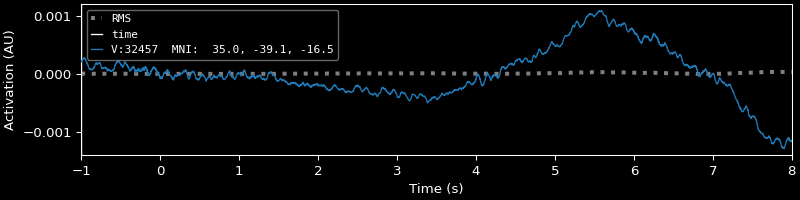

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


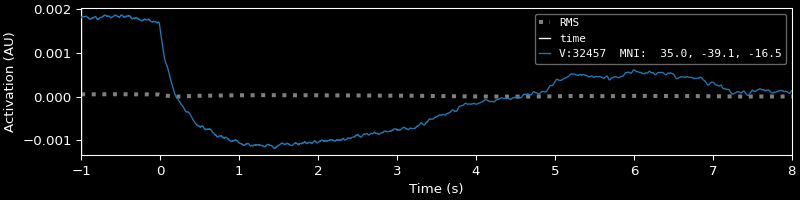

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


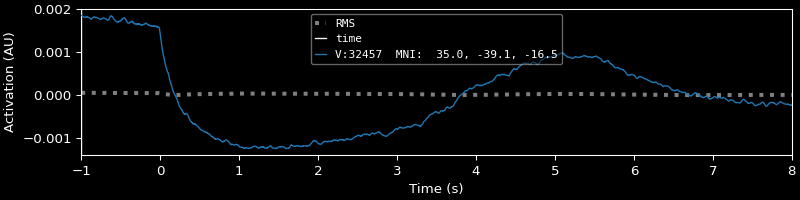

IMAGEIO FFMPEG_WRITER WARNING: input image is not divisible by macro_block_size=16, resizing from (800, 500) to (800, 512) to ensure video compatibility with most codecs and players. To prevent resizing, make your input image divisible by the macro_block_size or set the macro_block_size to 1 (risking incompatibility).


In [ ]:
fname_src = fs_subjects_dir / "PAT_3455" / "bem" / "PAT_3455-vol-5-src.fif"

if not fname_src.exists():
    vol_src = mne.setup_volume_source_space(
        fs_subject,
        pos=5.0,
        subjects_dir=str(fs_subjects_dir),
        verbose=True,
    )
    mne.write_source_spaces(fname_src, vol_src, overwrite=True)
else:
    vol_src = mne.read_source_spaces(fname_src)

diff = mne.combine_evoked([cond_distant_past, cond_distant_futur], weights=[1, -1])

evoked = [diff, cond_current, cond_never, cond_always, cond_past, cond_futur, cond_distant_past, cond_distant_futur]  # List of evoked objects for each condition
evoked_names = ['Diff', 'Current', 'Never', 'Always', 'Past', 'Futur', 'Distant Past', 'Distant Futur']

# TODO: zoom the video on the hippocampus
for i in range(len(evoked)):
    cond = evoked[i]
    name = evoked_names[i]
    #cond.pick(picks_hip)  # Keep only the channels of interest
    stc = mne.stc_near_sensors(
        cond,
        trans,
        fs_subject,
        subjects_dir=subjects_dir,
        src=vol_src,
        surface=None,
        verbose="error",
    )
    #stc = abs(stc)  # just look at magnitude
    #clim = dict(kind="value", lims=np.percentile(cond.data, [-75, -50, -10, 10, 50, 75])
    threshold = np.percentile(np.abs(cond.data), 75)
    mid = np.percentile(np.abs(cond.data), 50)
    low = np.percentile(np.abs(cond.data), 10)

    clim = dict(kind="value", pos_lims=[low, mid, threshold])
    brain = stc.plot_3d(
        src=vol_src,
        subjects_dir=subjects_dir,
        view_layout="horizontal",
        views=["axial", "coronal", "sagittal"],
        size=(800, 300),
        show_traces=0.4,
        clim=clim,
        add_data_kwargs=dict(colorbar_kwargs=dict(label_font_size=8)),
    )
    brain.save_movie(time_dilation=3, interpolation='linear', framerate=5, time_viewer=True, filename=f'videos/PAT_3455_ieeg_{str(name)}_{reference}.mp4')
    if i >= 2:
        break

#### Theta wave analysis

###### Frequency analysis

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


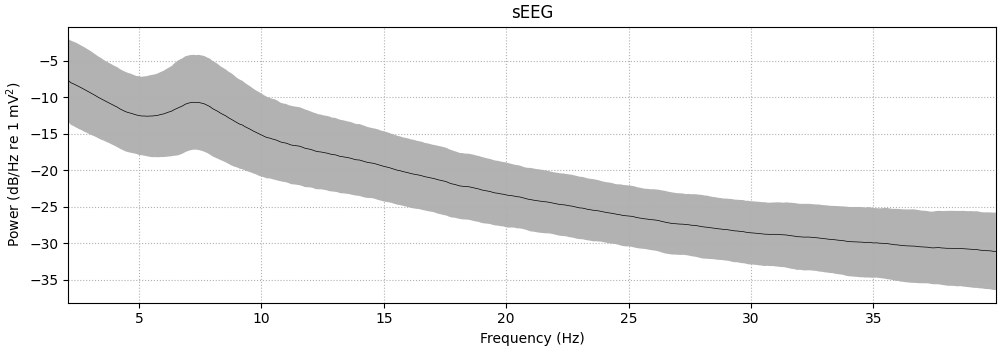

    Using multitaper spectrum estimation with 7 DPSS windows
Plotting power spectral density (dB=True).
Averaging across epochs before plotting...


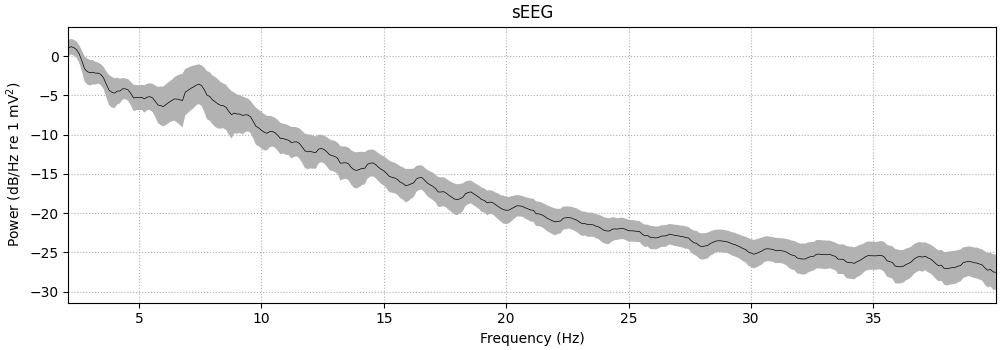

In [ ]:
epochs_ref.compute_psd(fmin=2.0, fmax=40.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}_psd_{reference}.png", dpi=300)
epochs.compute_psd(fmin=2.0, fmax=40.0).plot(
    average=True, amplitude=False, picks="data", exclude="bads"
).savefig(f"figures/{subject}_psd_no_reference.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows
Averaging across epochs before plotting...


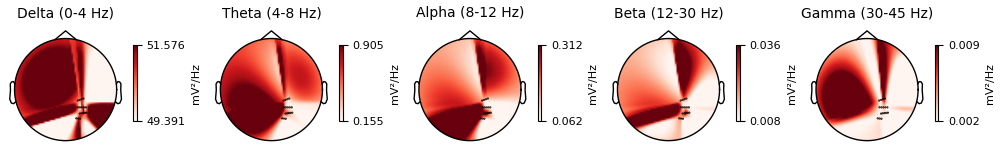

In [ ]:
# More suited for eeg with all electrodes
epochs.compute_psd().plot_topomap(ch_type=None, normalize=False, contours=0).savefig(f"figures/{subject}_psd_topomap.png", dpi=300)

In [ ]:
_, ax = plt.subplots()
spectrum = epochs.compute_psd(fmin=2.0, fmax=40.0, tmax=3.0, n_jobs=None)
# average across epochs first
mean_spectrum = spectrum.average()
psds, freqs = mean_spectrum.get_data(return_freqs=True)
# then convert to dB and take mean & standard deviation across channels
psds = 10 * np.log10(psds)
psds_mean = psds.mean(axis=0)
psds_std = psds.std(axis=0)

ax.plot(freqs, psds_mean, color="k")
ax.fill_between(
    freqs,
    psds_mean - psds_std,
    psds_mean + psds_std,
    color="k",
    alpha=0.5,
    edgecolor="none",
)
ax.set(
    title="Multitaper PSD (gradiometers)",
    xlabel="Frequency (Hz)",
    ylabel="Power Spectral Density (dB)",
)

ax.figure.savefig(f"figures/{subject}_psd_multitaper.png", dpi=300)

    Using multitaper spectrum estimation with 7 DPSS windows


###### Time-frequency analysis

In [ ]:
freqs = np.logspace(*np.log10([6, 35]), num=8)
n_cycles = freqs / 2.0  # different number of cycle per frequency
power, itc = epochs.compute_tfr(
    method="morlet",
    freqs=freqs,
    n_cycles=n_cycles,
    average=True,
    return_itc=True,
    decim=3,
)

###### Power

Applying baseline correction (mode: logratio)


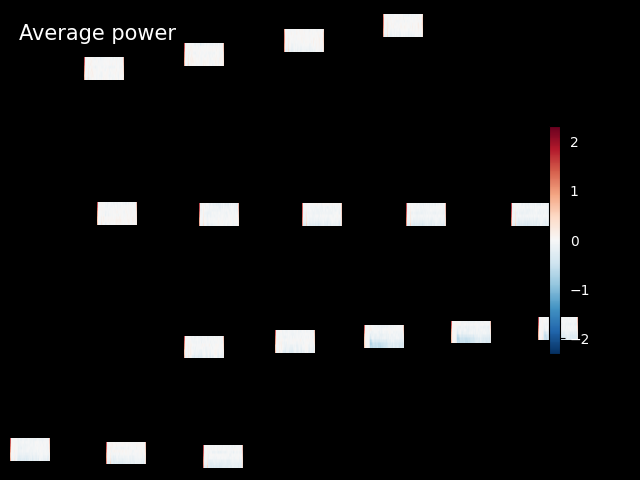

Applying baseline correction (mode: logratio)


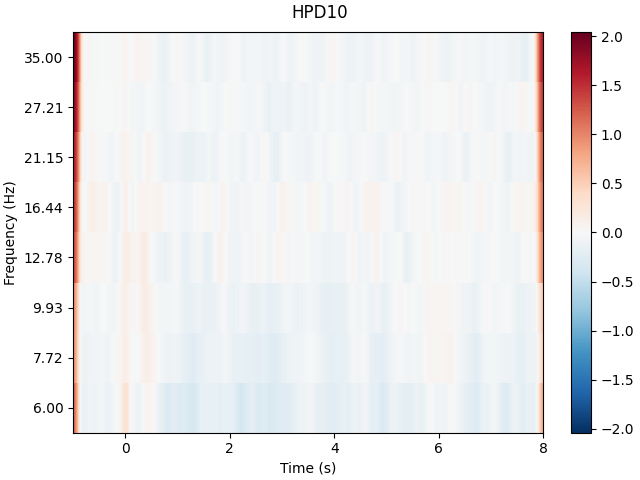

Applying baseline correction (mode: logratio)
Applying baseline correction (mode: logratio)


In [ ]:
power.plot_topo(baseline=(-0.5, 0), mode="logratio", title="Average power")
power.plot(picks=[10], baseline=(-0.5, 0), mode="logratio", title=power.ch_names[10])

fig, axes = plt.subplots(1, 2, figsize=(7, 4), layout="constrained")
topomap_kw = dict(
    ch_type=None, tmin=0.5, tmax=1.5, baseline=(-0.5, 0), mode="logratio", show=False
)
plot_dict = dict(Alpha=dict(fmin=8, fmax=12), Beta=dict(fmin=13, fmax=25))
for ax, (title, fmin_fmax) in zip(axes, plot_dict.items()):
    power.plot_topomap(**fmin_fmax, axes=ax, **topomap_kw)
    ax.set_title(title)
fig.savefig(f"figures/{subject}_tfr_topomap.png", dpi=300)

Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)
Applying baseline correction (mode: mean)


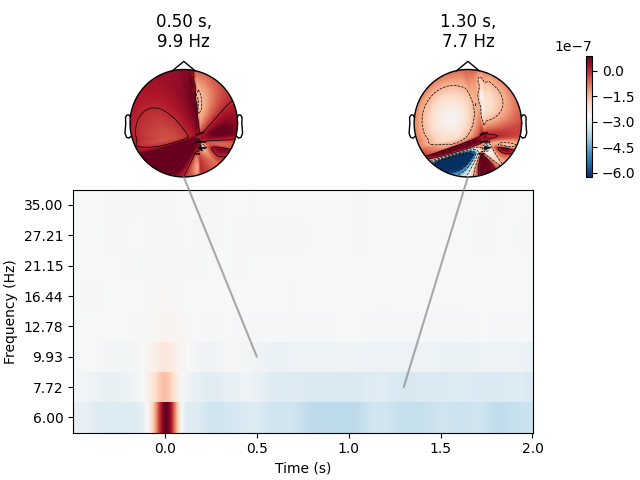

In [ ]:
power.plot_joint(
    baseline=(-0.5, 0), mode="mean", tmin=-0.5, tmax=2, timefreqs=[(0.5, 10), (1.3, 8)]
).savefig(f"figures/{subject}_tfr_joint.png", dpi=300)